
# Probabilistic Reasoning with Bayesian Networks and Particle Filters

## Introduction
Welcome to this practical notebook on probabilistic reasoning! In the real world, data is rarely perfect. We constantly deal with uncertainty, noise, and incomplete information. Probabilistic models give us a formal way to represent this uncertainty and make logical inferences.

In this notebook, we'll explore two powerful techniques:

**Bayesian Networks (BNs)**: These are graphical models that represent dependencies (or lack thereof) between different variables. They are used everywhere from medical diagnosis to spam filtering. We'll learn to build a BN and perform two types of inference:

**Exact Inference**: Calculating a precise probability.

**Approximate Inference**: Estimating a probability using sampling, which is essential when exact methods become too slow.

**Particle Filters (PFs)**: These are a brilliant solution for tracking a hidden state over time using noisy measurements. Think of tracking a robot in a building, a missile in the air, or even the state of the economy. PFs are a cornerstone of modern robotics and tracking systems.

We'll implement everything from scratch, step-by-step, to build a deep understanding. Let's get started!

###  Theoretical Foundations

A Bayesian Network (or "Bayes Net") is a *Directed Acyclic Graph* (DAG) that represents a set of variables and their conditional dependencies.

* **Nodes:** Each node in the graph represents a random variable (e.g., `Fever`, `Flu`).
* **Edges:** A directed edge from node A to node B means that A is a "parent" of B, and B's value *directly depends* on A's value.
* **Acyclicity:** You can't have loops (e.g., A -> B -> A), as this would represent a non-logical dependency.

**Conditional Independence**

The real power of BNs comes from the *lack* of edges. If there's no direct path or common parent structure connecting two variables, they might be **conditionally independent**. The key assumption of a BN is:

> **A node is conditionally independent of all its non-descendants, given its parents.**

This means to know the probability of `Fever`, you *only* need to know the state of its parents (e.g., `Flu`). You don't need to know about `Allergy` or `Cough` (unless they affect `Flu` itself).

This assumption allows us to simplify the "full joint probability" of all variables into a product of smaller, local probabilities. Instead of a giant table, we use the **chain rule for BNs**:

$$P(X_1, ..., X_n) = \prod_{i=1}^{n} P(X_i | \text{Parents}(X_i))$$

**CPTs**

Each node in the network has a **Conditional Probability Table (CPT)**.

* For *root nodes* (nodes with no parents, like `Flu`), the CPT is just its prior probability, $P(\text{Flu})$.
* For *child nodes* (nodes with parents, like `Fever`), the CPT specifies the probability of that node for *every possible combination* of its parents' values, e.g., $P(\text{Fever} | \text{Flu})$ and $P(\text{Fever} | \neg\text{Flu})$.

**Inference**

Inference is the process of "asking questions" of the network. We want to find the probability of a *query variable* ($Q$) given some *evidence* ($e$). We write this as **$P(Q | e)$**.

* **Example:** What is the probability a patient has the `Flu` ($Q$) given they have a `Fever` ($e$)? This is $P(\text{Flu} | \text{Fever})$.

## section 1:  - Building the Network

First, let's import libraries and define our network structure and CPTs in Python. We'll use simple dictionaries to store everything.

In [620]:
import numpy as np
import random
import matplotlib.pyplot as plt
import networkx as nx
import itertools

# We'll use 1 for True and 0 for False
TRUE = 1
FALSE = 0

# 1. Define the network structure
# A variable's key maps to a list of its parents
bn_structure = {
    "Flu": [],
    "Cold": [],
    "Allergy": [],
    "Fever": ["Flu"],
    "Cough": ["Cold"],
    "Fatigue": ["Flu"],
    "VisitDoctor": ["Fever", "Cough"]
}

# 2. Define the CPTs
# We use tuples of parent values as keys
bn_cpt = {
    # Priors (no parents)
    # Key: () (empty tuple)
    "Flu": {(): 0.05},
    "Cold": {(): 0.1},
    "Allergy": {(): 0.2},

    # P(Fever | Flu)
    # Key: (Flu_val,)
    "Fever": {
        (TRUE,): 0.9,  # P(Fever=T | Flu=T)
        (FALSE,): 0.2   # P(Fever=T | Flu=F)
    },

    # P(Cough | Cold)
    # Key: (Cold_val,)
    "Cough": {
        (TRUE,): 0.8,
        (FALSE,): 0.3
    },

    # P(Fatigue | Flu)
    # Key: (Flu_val,)
    "Fatigue": {
        (TRUE,): 0.7,
        (FALSE,): 0.2
    },

    # P(VisitDoctor | Fever, Cough)
    # Key: (Fever_val, Cough_val)
    "VisitDoctor": {
        (TRUE, TRUE): 0.95,   # P(Visit=T | Fever=T, Cough=T)
        (TRUE, FALSE): 0.95,  # P(Visit=T | Fever=T, Cough=F)
        (FALSE, TRUE): 0.95,  # P(Visit=T | Fever=F, Cough=T)
        (FALSE, FALSE): 0.1    # P(Visit=T | Fever=F, Cough=F)
    }
}

### Visualize the Network
Let's use networkx to draw the graph and confirm our structure is correct.

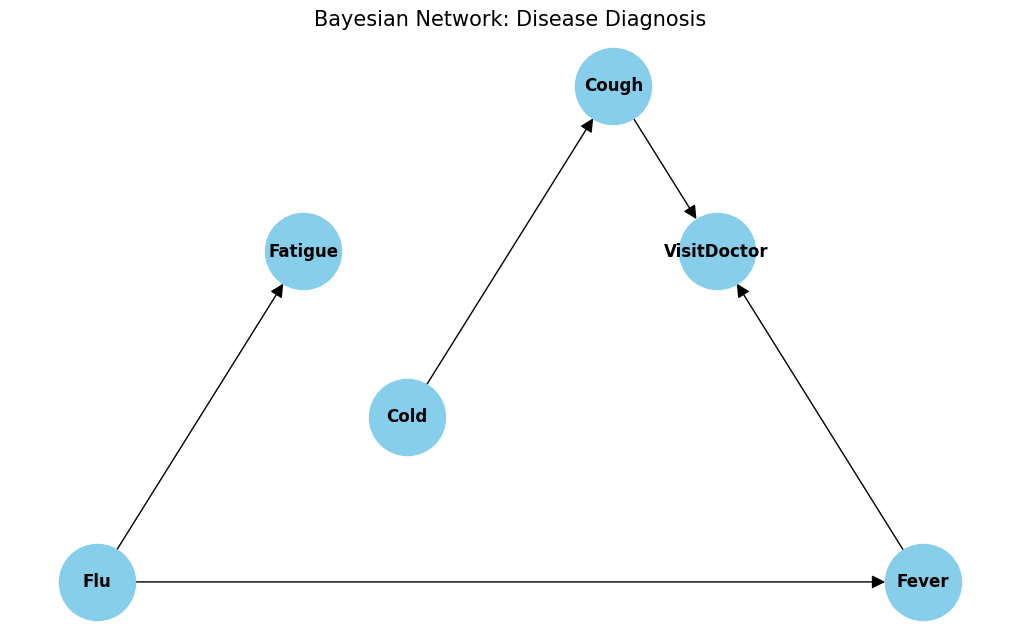

In [621]:
# Create a directed graph
G = nx.DiGraph()

# Add edges from parents to children
for child, parents in bn_structure.items():
    for parent in parents:
        G.add_edge(parent, child)

# Draw the graph
plt.figure(figsize=(10, 6))
pos = nx.planar_layout(G) # Use a layout that's often good for BNs
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='skyblue',
        font_size=12, font_weight='bold', arrowsize=20)
plt.title("Bayesian Network: Disease Diagnosis", size=15)
plt.show()

## Exact Inference

We want to calculate $P(Q | e)$. Using the definition of conditional probability:

$$P(Q | e) = \frac{P(Q, e)}{P(e)}$$

$P(e)$ is hard to compute directly. So, we introduce a normalization constant, $\alpha$:

$$P(Q | e) = \alpha P(Q, e)$$

where $\alpha = 1 / P(e)$. This lets us compute $P(Q=true, e)$ and $P(Q=false, e)$ and then just normalize them so they sum to 1.

How do we compute $P(Q, e)$? We have to "sum out" all the hidden variables ($H$) that are not $Q$ or $e$.

$$P(Q, e) = \sum_{h} P(Q, e, h)$$

This is called **enumeration**. We generate every single row of the full joint probability table that is consistent with our evidence $e$, calculate the probability of that row using our BN chain rule, and sum them up.

This is **computationally expensive** ($O(2^n)$ for $n$ variables), but it is *exact* and easy to implement for small networks.

> **💡 Theoretical Question 1:** Look at the network graph. Is `Cough` conditionally independent of `Fever`? Why or why not? What about `Fatigue` and `Cough`?
<div style="direction: rtl; text-align: justify; font-size: 16px; line-height: 1.8;">
    اگه روی VisitDoctor شرط نداشته باشیم اون وقت Cough و Fever مستقل میشوند اما اگه روی VisitDoctor شرط بزاریم در اون صورت Fever و Cough دیگر از هم مستقل نمی شوند<br>
    تنها مسیر بین Fatigue و Cough به صورت زیر هست :<br>
    Fatigue - Flu - Fever - VisitDocor - Cough
    حالا مسیر Cough - VisitDoctor - Fever یک مسیر inactive هست پس کل مسیر inactive میشه . پس تا وقتی که روی هیچ راسی شرط نزاشته باشیم Fatigue و Cough از هم مستقل میشوند.
</div>

In [622]:
# Cell: Exact inference helpers

def get_prob_from_cpt(var, val, assignment):
    """
    Helper function to get P(var=val | parents) from the CPTs.

    Parameters
    ----------
    var : str
        Variable name.
    val : int
        TRUE (1) or FALSE (0).
    assignment : dict
        Dictionary mapping variable -> value (0/1).
        Should contain values for this var's parents.

    Returns
    -------
    float
        P(var = val | parents(var))
    """
    parents = bn_structure[var]
    parent_vals = tuple(assignment[p] for p in parents)
    prob_true = bn_cpt[var][parent_vals]
    if val == TRUE:
        return prob_true
    else:
        return 1 - prob_true


def enumerate_all(vars_remaining, assignment):
    """
    Recursively computes P(assignment) by enumerating over vars_remaining.

    Parameters
    ----------
    vars_remaining : list of str
        Variables still to process.
    assignment : dict
        Current partial assignment (var -> value).

    Returns
    -------
    float
        Sum of probabilities over all completions of `assignment`.
    """
    if not vars_remaining:
        return 1.0
    y = vars_remaining[0]
    rest = vars_remaining[1:]
    if y in assignment:
        p_y = get_prob_from_cpt(y, assignment[y], assignment)
        return p_y * enumerate_all(rest, assignment)
    total = 0.0
    for val in [TRUE, FALSE]:
        new_assignment = dict(assignment)
        new_assignment[y] = val
        p_y = get_prob_from_cpt(y, val, new_assignment)
        total += p_y * enumerate_all(rest, new_assignment)
    return total


def exact_inference(query_var, evidence):
    """
    Computes P(query_var | evidence) using enumeration.

    Parameters
    ----------
    query_var : str
        The query variable (e.g., "Flu").
    evidence : dict
        Evidence assignment (e.g., {"Fever": TRUE, "Cough": TRUE}).

    Returns
    -------
    dict
        {
          f"P({query_var}=1 | e)": probability_of_true,
          f"P({query_var}=0 | e)": probability_of_false
        }
    """
    all_vars = list(bn_structure.keys())
    assign_true = dict(evidence)
    assign_true[query_var] = TRUE
    p_true = enumerate_all(all_vars, assign_true)
    assign_false = dict(evidence)
    assign_false[query_var] = FALSE
    p_false = enumerate_all(all_vars, assign_false)
    z = p_true + p_false
    p_true_norm = p_true / z
    p_false_norm = p_false / z
    return {
        f"P({query_var}=1 | e)": p_true_norm,
        f"P({query_var}=0 | e)": p_false_norm
    }
    


In [623]:
# Our evidence
evidence = {"Fever": TRUE, "Cough": TRUE}

# Run the query
exact_result = exact_inference("Flu", evidence)
print(f"Query: P(Flu | Fever=T, Cough=T)")
print(f"Exact Result: {exact_result}")

Query: P(Flu | Fever=T, Cough=T)
Exact Result: {'P(Flu=1 | e)': 0.1914893617021277, 'P(Flu=0 | e)': 0.8085106382978724}


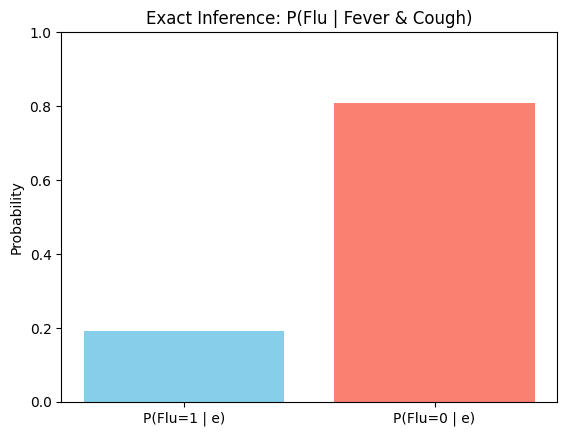

In [624]:
plt.bar(exact_result.keys(), exact_result.values(), color=['skyblue', 'salmon'])
plt.title("Exact Inference: P(Flu | Fever & Cough)")
plt.ylabel("Probability")
plt.ylim(0, 1)
plt.show()

## Approximate Inference

Our exact method was $O(2^n)$. If our network had 50 variables, this would be impossible ($2^{50} \approx 10^{15}$ operations). We need a way to *approximate* the answer.

**Sampling** is the key. If we could just generate a million patient samples from the *posterior* distribution $P(Q | e)$, we could just count how many have `Flu=T` vs `Flu=F`. But we can't... because $P(Q|e)$ is what we're trying to find!

**Likelihood Weighting (LW)** is a clever solution.

1.  We generate `N` samples (e.g., `N=10000`).
2.  For each sample, we iterate through the variables in "topological order" (parents before children).
3.  **If the variable is *not* evidence:** We sample it randomly based on its CPT (given its parents, which we've already sampled).
4.  **If the variable *is* evidence (e.g., `Fever=T`):** We do *not* sample. We "fix" its value to the evidence. But to account for this, we multiply the sample's "weight" by the likelihood of that evidence: $w = w \times P(\text{Fever}=T | \text{parents})$.
5.  At the end, each sample has a *weight* ($w$) that represents how likely that sample is, given the evidence.
6.  To get our final answer, we don't just count samples. We compute a *weighted sum*. The total probability of `Flu=T` is (Sum of weights of `Flu=T` samples) / (Sum of all weights).

This works much better than simple rejection sampling (where we'd throw away any sample that *doesn't* match the evidence).

...

> **💡 Theoretical Question 2:** In Likelihood Weighting, what would happen if your evidence was extremely rare (e.g., $P(e) = 0.000001$)? How would this affect the *efficiency* of the algorithm (i.e., how many samples `N` would you need to get a stable answer)?
<div style="direction: rtl; text-align: justify; font-size: 16px; line-height: 1.8;">
    اگه شواهد خیلی نادر باشن اون وقت به این معنی هست که احتمال ها خیلی کوچک هستن و در نتیجه بیشتر نمونه ها وزن کوچیک و خیلی متفاوت میگیرن همچنین تعداد کمی نمونه وزن نسبتا بزرگی میگیرن و عملا جمع کل وزن هارو این نمونه های خاص مشخص میکنن بنابراین بقیه نمونه ها تقریبا بی اثر میشوند . در نتیجه این اتفاق باعث میشه واریانس تخمین خیلی بالابره چون چند تا نمونه ای که وزن زیاد رو دارن نتیجه رو میسازن و این اتفاق باعث میشه اگر شواهد نادر باشند likelihood weightimg خیلی ناکارآمد بشه و برای اینکه این مشکل رو حل کنیم باید N رو خیلی زیاد کنیم 
</div>

In [625]:
# Cell: Likelihood weighting

def likelihood_weighting(query_var, evidence, N=1000):
    """
    Performs approximate inference using Likelihood Weighting.

    Parameters
    ----------
    query_var : str
        Query variable name (e.g., "Flu").
    evidence : dict
        Evidence assignment, e.g. {"Fever": TRUE, "Cough": TRUE}.
    N : int
        Number of samples to generate.

    Returns
    -------
    dict
        {
          f"P({query_var}=1 | e)": approx_prob_true,
          f"P({query_var}=0 | e)": approx_prob_false
        }
    """
    all_vars = list(bn_structure.keys())
    weighted_counts = {
        TRUE: 0.0,
        FALSE: 0.0
    }
    for _ in range(N):
        assignment = {}
        sample_weight = 1.0
        for var in all_vars:
            if var in evidence:
                val = evidence[var]
                assignment[var] = val
                prob_e = get_prob_from_cpt(var, val, assignment)
                sample_weight *= prob_e
            else:
                prob_true = get_prob_from_cpt(var, TRUE, assignment)
                r = random.random()
                if r < prob_true:
                    assignment[var] = TRUE
                else:
                    assignment[var] = FALSE
        query_val = assignment[query_var]
        weighted_counts[query_val] += sample_weight
    total_weight = weighted_counts[TRUE] + weighted_counts[FALSE]

    if total_weight == 0.0:
        approx_prob_true = 0.0
        approx_prob_false = 0.0
    else:
        approx_prob_true = weighted_counts[TRUE] / total_weight
        approx_prob_false = weighted_counts[FALSE] / total_weight
    return {
        f"P({query_var}=1 | e)": approx_prob_true,
        f"P({query_var}=0 | e)": approx_prob_false
    }


In [626]:
# Same evidence
evidence = {"Fever": TRUE, "Cough": TRUE}
num_samples = 10000

# Run the query
approx_result = likelihood_weighting("Flu", evidence, N=num_samples)
print(f"Query: P(Flu | Fever=T, Cough=T)")
print(f"Approx. Result (N={num_samples}): {approx_result}")

Query: P(Flu | Fever=T, Cough=T)
Approx. Result (N=10000): {'P(Flu=1 | e)': 0.1912341910161589, 'P(Flu=0 | e)': 0.808765808983841}


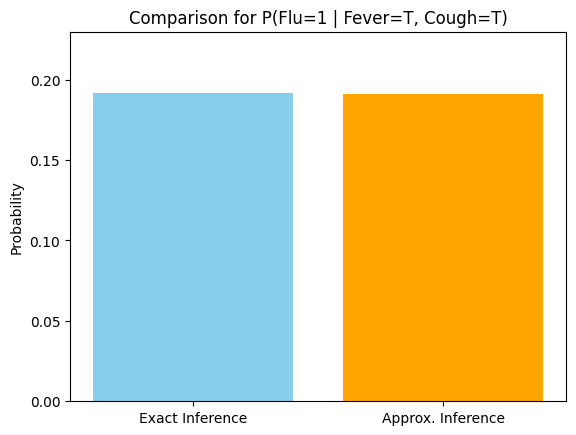

In [627]:
# Get the P(Flu=T) values
exact_p = exact_result[f"P(Flu=1 | e)"]
approx_p = approx_result[f"P(Flu=1 | e)"]

plt.bar(["Exact Inference", "Approx. Inference"],
        [exact_p, approx_p],
        color=['skyblue', 'orange'])
plt.title(f"Comparison for P(Flu=1 | Fever=T, Cough=T)")
plt.ylabel("Probability")
plt.ylim(0, max(exact_p, approx_p) * 1.2)
plt.show()

### Section 2.1: Particle Filters

**What is State Estimation?**

We often want to know the *state* of a system (e.g., a robot's position) that we cannot see directly. This is a **hidden state**. We can, however, get *measurements* or *observations* (e.g., from a noisy sensor) that are related to the state.

The goal of state estimation is to maintain a *belief* about the robot's true position, given all the measurements we've seen so far. This is $P(X_t | z_{1:t})$.

**The Bayes Filter**

The core of this is a recursive two-step process called the **Bayes Filter**:

1.  **Prediction (Motion Update):**
    * We have a belief about the position at $t-1$, $Bel(X_{t-1})$.
    * The robot moves. We use a *transition model* $P(X_t | X_{t-1})$ (the "motion model") to predict where it *might* be now.
    * This "blurs" our belief, as the motion itself is uncertain.
    * $\text{Predicted_Bel}(X_t) = \int P(X_t | X_{t-1}) Bel(X_{t-1}) dX_{t-1}$

2.  **Correction (Measurement Update):**
    * We get a new sensor reading, $z_t$.
    * We use a *sensor model* $P(z_t | X_t)$ to see how *likely* our predicted positions are. If a position $X_t$ would make $z_t$ very likely, we increase our belief in $X_t$.
    * This uses Bayes' rule to "sharpen" our belief.
    * $Bel(X_t) = \eta P(z_t | X_t) \times \text{Predicted_Bel}(X_t)$
    * ($\eta$ is a normalizer, just like $\alpha$ before).

**What is a Particle Filter?**

The problem is that $Bel(X)$ is a continuous probability distribution. It's hard to represent.

A **Particle Filter** is a way to *approximate* this $Bel(X)$ distribution using a set of `N` discrete samples, called **particles**.

* Each particle $p_i$ is a *hypothesis* of the true state (e.g., $p_i = \text{"robot is at position 5"}$).
* A dense cloud of particles represents high belief. A sparse area represents low belief.

The Bayes Filter steps are now implemented with particles:

1.  **Initialize:** Spread `N` particles (e.g., uniformly) to represent "I don't know where I am."
2.  **Prediction (Motion):** For *each* particle, move it *individually* according to the motion model (e.g., add some random noise).
3.  **Correction (Weighting):** For *each* particle, calculate its *importance weight*. This weight is $w_i = P(z_t | p_i)$, i.e., "how likely is the sensor reading $z_t$ if the robot was *really* at this particle's position $p_i$?"
4.  **Resampling:** This is the magic step. We create a *new* set of `N` particles by sampling *with replacement* from our old set, where the probability of picking a particle is proportional to its weight.
    * Particles with high weights (good hypotheses) get copied multiple times.
    * Particles with low weights (bad hypotheses) are likely to die out.
5.  Go to Step 2.

This is often called **Sequential Importance Resampling (SIR)**.

### Section 2.2: Problem Definition Environment:
A 1D "hallway" with grid_size = 30 cells (positions 0 to 29). True State ($X_t$): The robot's actual integer position.
This is hidden from us.Motion Model ($P(X_t | X_{t-1})$): With 80% probability, move $\pm 1$ cell (equal chance). With 20% probability, stay in place. (Robot cannot move off the grid).

Sensor Model ($P(z_t | X_t)$): The robot gets a noisy measurement $z_t$. With 60% prob, $z_t = X_t$ (correct). With 20% prob, $z_t = X_t - 1$ (off by one).With 20% prob, $z_t = X_t + 1$ (off by one).Goal: Use a particle filter to estimate $X_t$ over 20 time steps.

### Section 2.3: Step 1 - Initialization
we first define our environment and initialize our particles. We'll start with N=500 particles, spread uniformly across the grid. This represents our initial belief: "The robot could be anywhere."

In [628]:
grid_size = 30
num_particles = 500
num_timesteps = 20

# 1. Initialize Particles
# Create 500 particles, each with a random integer position 0-29
particles = np.random.randint(0, grid_size, size=num_particles)

# 2. Initialize a true starting position for the robot (this is hidden!)
true_position = np.random.randint(0, grid_size)

print(f"True robot starting position: {true_position}")
print(f"First 10 particles: {particles[:10]}")

True robot starting position: 19
First 10 particles: [20 22 16  1 25 15 20 21  8 11]


**Visualize Initial Belief**

A histogram is a perfect way to see our particle distribution (our belief).

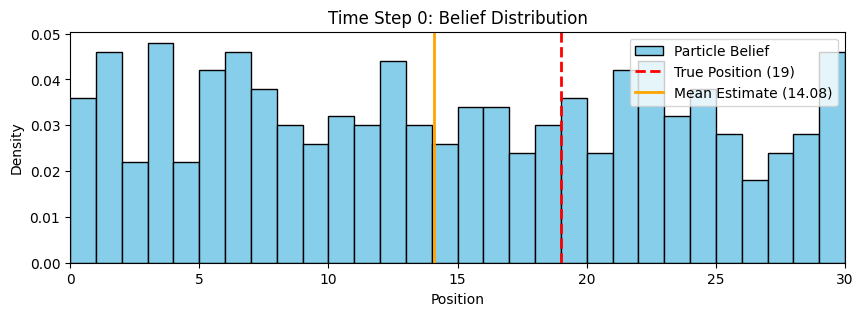

In [629]:
def plot_particles(particles, true_pos, step):
    plt.figure(figsize=(10, 3))
    # Plot the histogram of particle positions
    plt.hist(particles, bins=np.arange(0, grid_size + 1), density=True,
             color='skyblue', edgecolor='black', label='Particle Belief')

    # Plot a vertical line for the true position
    plt.axvline(true_pos, color='red', linestyle='dashed',
                linewidth=2, label=f'True Position ({true_pos})')

    # Plot a vertical line for the mean particle estimate
    mean_est = np.mean(particles)
    plt.axvline(mean_est, color='orange', linestyle='solid',
                linewidth=2, label=f'Mean Estimate ({mean_est:.2f})')

    plt.title(f"Time Step {step}: Belief Distribution")
    plt.xlabel("Position")
    plt.ylabel("Density")
    plt.legend()
    plt.xlim(0, grid_size)
    plt.show()

plot_particles(particles, true_position, step=0)

### Section 2.4: Step 2 - Motion Update (Prediction)
Now, we implement the move_particles function. This takes our list of particles and moves each one according to the motion model.

True robot moved to: 18
First 10 particles moved to: [19 21 16  2 24 14 21 20  7 12]


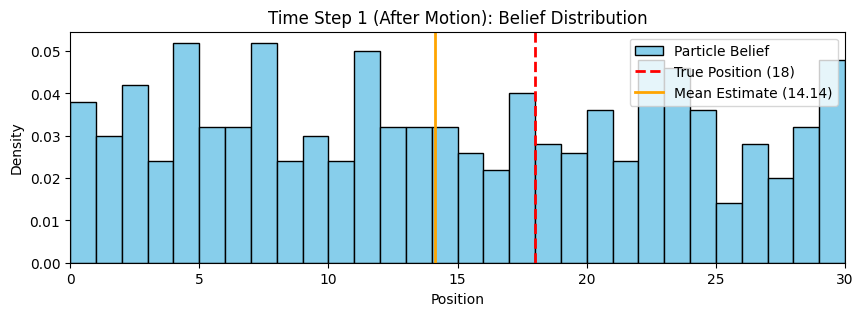

In [630]:
# Cell: Motion model

def move_particles(particles):
    """
    Apply the motion model to each particle.

    Motion model:
    - With 80% probability, move +/- 1 cell (equal chance).
    - With 20% probability, stay in place.
    - Keep particles within [0, grid_size - 1].
    """
    new_parts = particles.copy()
    for i in range(len(new_parts)):
        r = random.random()
        if r < 0.8:
            step = 1 if random.random() < 0.5 else -1
            new_parts[i] += step
        new_parts[i] = max(0, min(grid_size - 1, new_parts[i]))
    return new_parts

true_position = move_particles(np.array([true_position]))[0]
print(f"True robot moved to: {true_position}")

particles = move_particles(particles)
print(f"First 10 particles moved to: {particles[:10]}")

plot_particles(particles, true_position, step="1 (After Motion)")


### Section 2.5: Step 3 - Measurement Update (Correction)
Now we get a sensor reading. Let's simulate one based on the true_position.

In [631]:
# Cell: Sensor model

def get_sensor_reading(true_pos):
    """
    Simulate a noisy sensor reading based on the true position.

    Sensor model:
    - 60%: z_t = X_t  (correct)
    - 20%: z_t = X_t - 1
    - 20%: z_t = X_t + 1
    (We ignore bounds for simplicity.)
    """
    r = random.random()
    if r < 0.6:
        z = true_pos
    elif r < 0.8:
        z = true_pos - 1
    else:
        z = true_pos + 1
    z = max(0, min(grid_size - 1, z))
    return z

observation = get_sensor_reading(true_position)
print(f"True Position: {true_position}")
print(f"Noisy Observation: {observation}")


True Position: 18
Noisy Observation: 18


Now, we write the measurement_weight function. This is the core of the correction step. It calculates the likelihood $P(z_t | X_t)$ for each particle.

In [632]:
# Cell: Measurement likelihood

def get_particle_weight(particle_pos, observation):
    """
    Calculates the weight P(observation | particle_pos).

    According to the sensor model:
    - If particle_pos == observation: weight = 0.6
    - If |particle_pos - observation| == 1: weight = 0.2
    - Else: weight = 0.0
    """
    if particle_pos == observation:
        return 0.6
    elif abs(particle_pos - observation) == 1:
        return 0.2
    else:
        return 0.0




observation = get_sensor_reading(true_position)
weights = np.array([get_particle_weight(p, observation) for p in particles])
weights = weights + 1e-10  # avoid division by zero
weights = weights / np.sum(weights)

print(f"First 10 particle positions: {particles[:10]}")
print(f"First 10 weights: {weights[:10]}")


First 10 particle positions: [19 21 16  2 24 14 21 20  7 12]
First 10 weights: [1.33333333e-02 6.66666664e-12 6.66666664e-12 6.66666664e-12
 6.66666664e-12 6.66666664e-12 6.66666664e-12 6.66666664e-12
 6.66666664e-12 6.66666664e-12]


### Section 2.6: Step 4 - Resampling
Our particles now have weights, but they are still in their "predicted" (blurry) positions. We need to create a new set of particles that reflects our "corrected" belief.

We will sample num_particles times from our current particle list. The probability of picking a particle is its weight.

np.random.choice does this for us perfectly!

First 10 particles *after* resampling: [18 18 18 18 18 17 19 19 18 18]


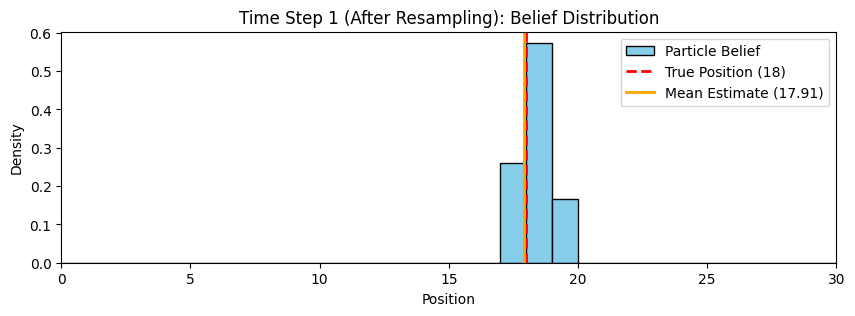

In [633]:
# Cell: Resampling

def resample_particles(particles, weights):
    """
    Resamples N particles based on their weights.

    Use np.random.choice to select indices with probabilities given by `weights`.
    """
    idx = np.random.choice(len(particles), size=num_particles, p=weights, replace=True)
    return particles[idx]


particles = resample_particles(particles, weights)
print(f"First 10 particles *after* resampling: {particles[:10]}")
plot_particles(particles, true_position, step="1 (After Resampling)")


### Section 2.7: Step 5 - The Full Filter Loop

Step 0: True pos = 23, Observation = 23, Mean Est = 22.94


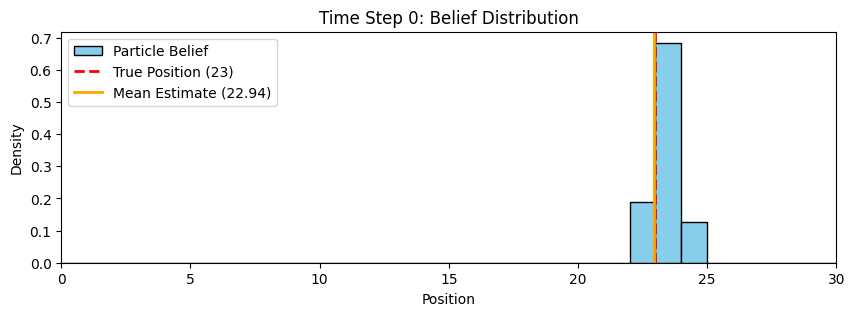

Step 4: True pos = 22, Observation = 21, Mean Est = 22.00


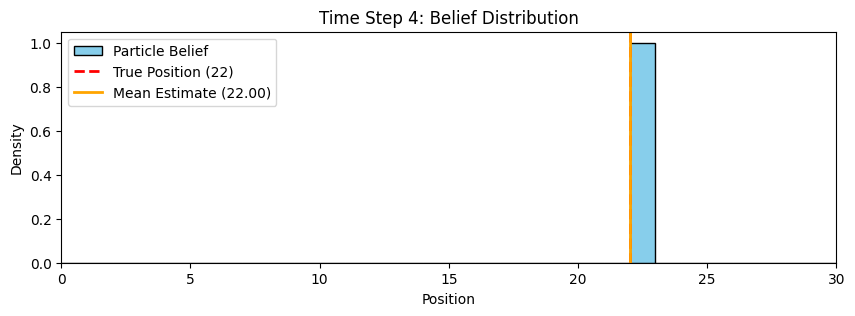

Step 8: True pos = 20, Observation = 21, Mean Est = 21.20


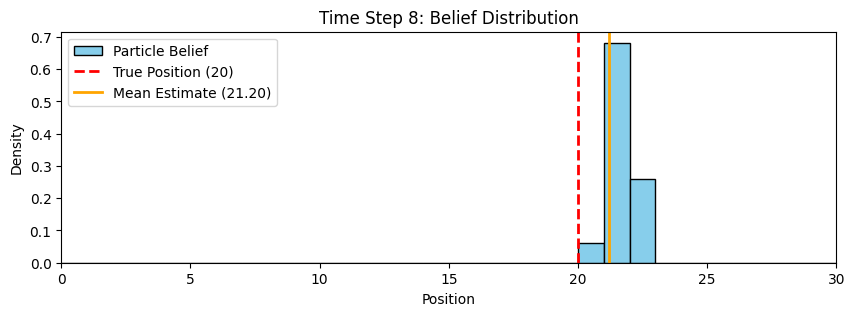

Step 12: True pos = 23, Observation = 23, Mean Est = 22.81


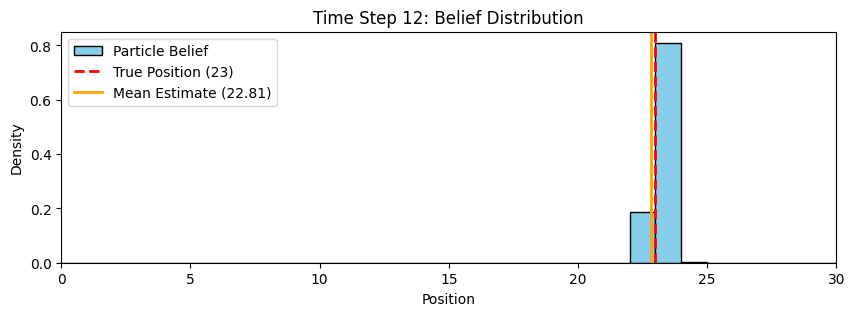

Step 16: True pos = 24, Observation = 24, Mean Est = 23.87


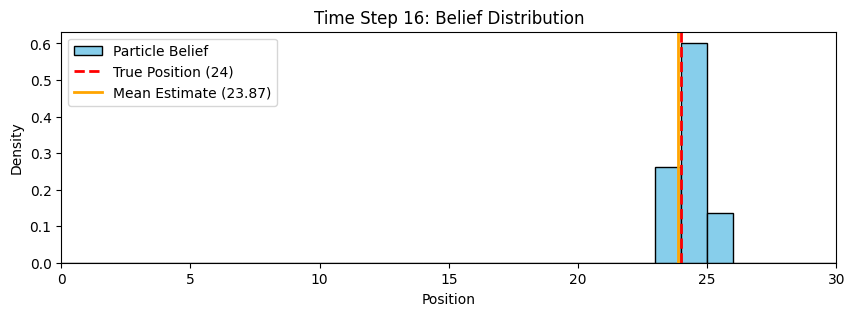

Step 19: True pos = 27, Observation = 27, Mean Est = 26.83


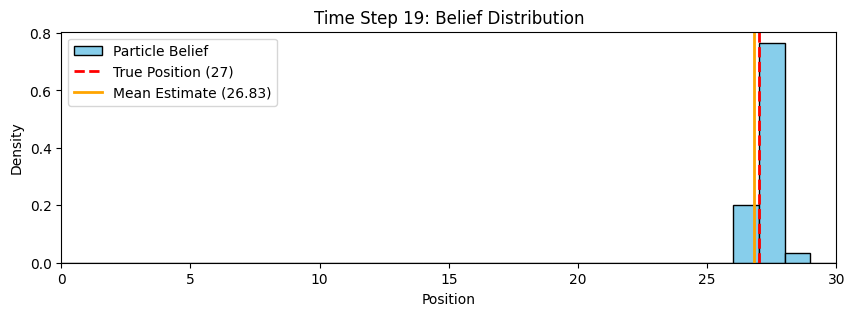

Simulation complete.


In [634]:
# Cell: Full particle filter loop

# --- Reset and run the full simulation ---

# Initialization
particles = np.random.randint(0, grid_size, size=num_particles)
true_position = np.random.randint(0, grid_size)

# Lists to store history for plotting
true_history = []
mean_est_history = []

for t in range(num_timesteps):
    true_position = move_particles(np.array([true_position]))[0]
    observation = get_sensor_reading(true_position)
    particles = move_particles(particles)
    weights = np.array([get_particle_weight(p, observation) for p in particles])
    weights = weights + 1e-10
    weights = weights / np.sum(weights)
    particles = resample_particles(particles, weights)
    true_history.append(true_position)
    mean_est_history.append(np.mean(particles))
    if t % 4 == 0 or t == num_timesteps - 1:
        print(f"Step {t}: True pos = {true_position}, Observation = {observation}, Mean Est = {np.mean(particles):.2f}")
        plot_particles(particles, true_position, step=f"{t}")

print("Simulation complete.")


### Section 2.8: Analysis
The best way to see how well our filter worked is to plot the true position and our filter's mean estimate over time.

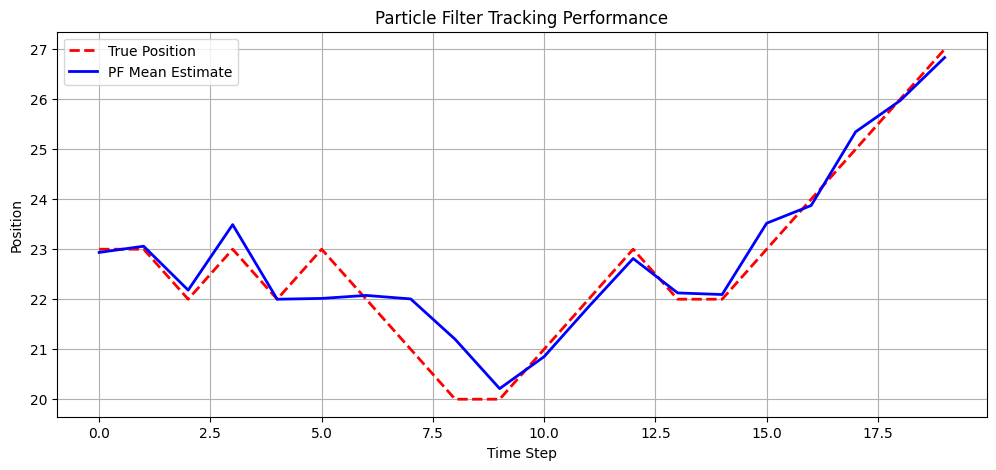

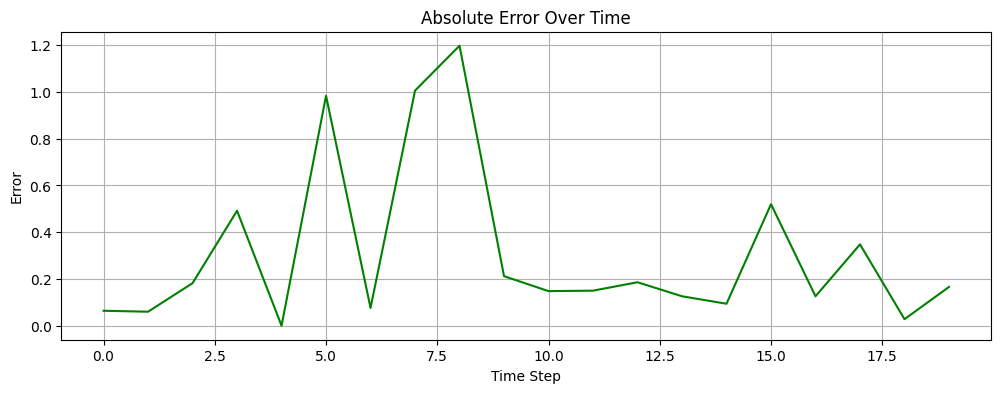

In [635]:
plt.figure(figsize=(12, 5))
plt.plot(true_history, 'r--', label='True Position', linewidth=2)
plt.plot(mean_est_history, 'b-', label='PF Mean Estimate', linewidth=2)
plt.title("Particle Filter Tracking Performance")
plt.xlabel("Time Step")
plt.ylabel("Position")
plt.legend()
plt.grid(True)
plt.show()

# Calculate and plot the error
error = np.abs(np.array(true_history) - np.array(mean_est_history))
plt.figure(figsize=(12, 4))
plt.plot(error, 'g-')
plt.title("Absolute Error Over Time")
plt.xlabel("Time Step")
plt.ylabel("Error")
plt.grid(True)
plt.show()

> **💡 Theoretical Question 3:** What do you think would happen if we *never* did the Resampling step (Step 4)? What would happen to the particle weights over time? (This is known as sample impoverishment or degeneracy).
<div style="direction: rtl; text-align: justify; font-size: 16px; line-height: 1.8;">
    اگه resampling انجام نشه اون وقت وزن ها به مرور نابرابر و ناپدید میشن چون هربار که likelihood  رو اعمال میکنیم تنها چند تا ذره مقدار likelihood نسبتا بزرگی میگیرن و درنتیجه بعد چند iteration تقریبا همه ذرات وزن نزدیک به صفر میگیرن و فقط یک یا دو ذره ورن معنی داری خواهند داشت . در نتیجه کل posterior با یک ذره نشون داده میشه . و اینکار باعث میشه likelihood weighting ناکارآمد بشه . حالا برای رفع این مشکل Resampling انجام میدیم که باعث میشه ذرات با وزن زیاد تکثیر بشن و ذرات با وزن خیلی کم حذف بشن و در نتیجه ما یک جمعیت جدید میسازیم که وزن ذرات در اون جمعیت تقریبا برابر هست و تعداد بیشتری از ذرات در نواحی ای قرار میگیرن که واقعا محتمل هستند و همین باعث میشه بعد از چند iteraion یک یا دو ذره برامون نمونه و ذرات بیشتری در ناحیه های پراحتمال حضور داشته باشند .
</div>


> **💡 Theoretical Question 4:** What is the trade-off in choosing `num_particles`? What would happen if you used `N=10`? What about `N=50000`?
<div style="direction: rtl; text-align: justify; font-size: 16px; line-height: 1.8;">
    N=10 :<br>
    در این حالت ذرات بسیار کم هستند - پوشش فضای حالت ضعیف هست - احتمال اینکه همه ذرات در یک منطقه گیر بیفند زیاد هست - دقت posterior خیلی پایین میاد - الگوریتم ناپایدار میشه و نویزش زیاد میشه - Degeneracy سریع تر اتاق میفته - واریانس زیاد میشه
    <br>N=5000 :<br>
    فضای حالت خوب پوشش داده میشه - تخمین posterior دقیق تر میشه - واریانس کمتر میشع - اثر نویز توی اندازه گیری کمتر میشه - احتمال degeneracy کم میشه
    اما این این N معایبی هم داره مثلا هزینه محاسباتی رو زیاد میکند همچنین هر iteration ممکنه چندین برابر کند تر بشه و همچنین به RAM بیشتری نیاز خواهیم داشت .
</div>

### Conclusion

1. Bayesian Networks give us a powerful and efficient way to model complex systems with uncertain variables. The "chain rule" and the concept of conditional independence are key.

2. Exact Inference (like enumeration) is precise but becomes computationally impossible for large networks.

3. Approximate Inference (like Likelihood Weighting) uses sampling to estimate probabilities. It scales to large networks and is the basis for most modern probabilistic programming.

4. Particle Filters are a brilliant solution to the non-linear/non-Gaussian tracking problem. They work by "simulating" many hypotheses (particles) and using sensor data to "kill" bad ones and "clone" good ones.

5. The Predict-Correct cycle (or Motion-Measurement-Resample) is a fundamental pattern in all forms of state estimation.

6. These concepts are the foundation for everything from self-driving car navigation and financial modeling to building smarter diagnostic tools.